# Урок 15.10. Ряды: бесконечные суммы

**Интерактивная версия:** `lessons/lesson_15_10/web/index.html`

После урока вы сможете:

- объяснять сумму ряда как предел частичных сумм, находить суммы телескопических и геометрических рядов и оценивать остаток;
- распознавать ловушки бесконечных сумм: скобки, алгебру с расходящимися рядами, перестановки;
- исследовать положительные ряды необходимым условием, сравнением, интегральным признаком, признаками Д’Аламбера и Коши;
- применять признак Лейбница с оценкой ошибки и различать абсолютную и условную сходимость;
- находить радиус сходимости степенного ряда и получать новые ряды почленным дифференцированием и интегрированием;
- объяснять радиус сходимости особыми точками (в том числе для логистических потерь) и считать рядами Тейлора без потери точности;
- раскладывать функции в ряд Фурье и связывать гладкость, убывание коэффициентов и явление Гиббса;
- описывать бустинг, темп ν, раннюю остановку, экспоненциальное среднее и расписания темпа SGD на языке рядов.

Разделы ноутбука идут в том же порядке, что и 30 шагов урока (семь блоков). Каждое утверждение проверяется
числом, ключевые — сверкой с `scipy`, `scikit-learn` и учебной библиотекой `gbcourse`.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation
from scipy import special

from gbcourse import datasets
from gbcourse.boosting import GBRegressor
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED, VIOLET

use_course_style()
plt.rcParams["animation.embed_limit"] = 30


def partial_sums(a, n, start=1):
    """Частичные суммы S_1 … S_n ряда с членами a(k), k = start, start + 1, …"""
    return np.cumsum([a(k) for k in range(start, start + n)])

## Блок 1. Ряд и его сумма

### Интуиция и шаг 1: частичные суммы

$\frac12 + \frac14 + \dots$: после $n$ кусочков не заполнено ровно $2^{-n}$. Члены и частичные суммы задают друг
друга: $a_n = S_n - S_{n-1}$.

In [2]:
S = partial_sums(lambda k: 0.5**k, 20)
for n in (1, 2, 3, 10, 20):
    print(f"S_{n:<2} = {S[n - 1]:.7f},  осталось {1 - S[n - 1]:.2e}")
print("Σ k² для k = 1..4:", sum(k * k for k in range(1, 5)))
Sn = lambda n: n / (n + 1)  # noqa: E731
print("члены по суммам S_n = n/(n+1):", [round(Sn(n) - Sn(n - 1), 6) for n in range(1, 6)], "= 1/(n(n+1)):", [round(1 / (n * (n + 1)), 6) for n in range(1, 6)])

S_1  = 0.5000000,  осталось 5.00e-01
S_2  = 0.7500000,  осталось 2.50e-01
S_3  = 0.8750000,  осталось 1.25e-01
S_10 = 0.9990234,  осталось 9.77e-04
S_20 = 0.9999990,  осталось 9.54e-07
Σ k² для k = 1..4: 30
члены по суммам S_n = n/(n+1): [0.5, 0.166667, 0.083333, 0.05, 0.033333] = 1/(n(n+1)): [0.5, 0.166667, 0.083333, 0.05, 0.033333]


### Шаг 2. Сумма ряда — предел; номер N(ε)

In [3]:
def n_of_eps(sums, limit, eps):
    """Первый номер, после которого все суммы лежат в полосе limit ± eps."""
    bad = np.nonzero(np.abs(sums - limit) >= eps)[0]
    return int(bad[-1]) + 2 if len(bad) else 1


geo = partial_sums(lambda k: 0.5**k, 3000)
basel = partial_sums(lambda k: 1 / k**2, 3000)
alt = partial_sums(lambda k: (-1) ** (k + 1) / k, 3000)
for eps in (0.1, 0.01, 0.001):
    print(f"ε = {eps}: N для ½ⁿ — {n_of_eps(geo, 1, eps)}, для Σ1/k² — {n_of_eps(basel, math.pi**2 / 6, eps)}, для ln 2 — {n_of_eps(alt, math.log(2), eps)}")
assert n_of_eps(geo, 1, 1e-3) == 10

ε = 0.1: N для ½ⁿ — 4, для Σ1/k² — 10, для ln 2 — 5
ε = 0.01: N для ½ⁿ — 7, для Σ1/k² — 100, для ln 2 — 50
ε = 0.001: N для ½ⁿ — 10, для Σ1/k² — 1000, для ln 2 — 500


### Шаг 3. Телескопические ряды

In [4]:
tele = {
    "1/(k(k+1)) → 1": (lambda k: 1 / (k * (k + 1)), 1.0),
    "2/(k(k+2)) → 3/2": (lambda k: 2 / (k * (k + 2)), 1.5),
    "1/(k(k+1)(k+2)) → 1/4": (lambda k: 1 / (k * (k + 1) * (k + 2)), 0.25),
    "1/√k − 1/√(k+1) → 1": (lambda k: 1 / math.sqrt(k) - 1 / math.sqrt(k + 1), 1.0),
}
for name, (a, _lim) in tele.items():
    s = partial_sums(a, 100000)
    print(f"{name:24}: S_10 = {s[9]:.6f}, S_100000 = {s[-1]:.6f}")
print("ln(1 + 1/k): S_99 =", partial_sums(lambda k: math.log(1 + 1 / k), 99)[-1], " = ln 100 =", math.log(100), "→ ∞")
assert abs(partial_sums(lambda k: 1 / (k * (k + 1)), 10)[-1] - 10 / 11) < 1e-14

1/(k(k+1)) → 1          : S_10 = 0.909091, S_100000 = 0.999990
2/(k(k+2)) → 3/2        : S_10 = 1.325758, S_100000 = 1.499980
1/(k(k+1)(k+2)) → 1/4   : S_10 = 0.246212, S_100000 = 0.250000
1/√k − 1/√(k+1) → 1     : S_10 = 0.698489, S_100000 = 0.996838
ln(1 + 1/k): S_99 = 4.60517018598809  = ln 100 = 4.605170185988092 → ∞


### Шаг 4. Ловушки: скобки в расходящемся ряде и алгебра с несуществующим числом

In [5]:
grandi = partial_sums(lambda k: (-1) ** (k + 1), 12)
print("ряд Гранди: суммы", grandi.astype(int).tolist())
print("скобки (1 − 1) + …  → чётные суммы:", grandi[1::2].astype(int).tolist())
print("1 + (−1 + 1) + …    → нечётные суммы:", grandi[0::2].astype(int).tolist())
print("1 + 2 + 4 + …: суммы", partial_sums(lambda k: 2 ** (k - 1), 10).astype(int).tolist(), "— «S = −1» бессмыслица")
print("сходящийся 1 − ½ + ¼ − …:", partial_sums(lambda k: (-0.5) ** (k - 1), 60)[-1], "= 2/3")

ряд Гранди: суммы [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
скобки (1 − 1) + …  → чётные суммы: [0, 0, 0, 0, 0, 0]
1 + (−1 + 1) + …    → нечётные суммы: [1, 1, 1, 1, 1, 1]
1 + 2 + 4 + …: суммы [1, 3, 7, 15, 31, 63, 127, 255, 511, 1023] — «S = −1» бессмыслица
сходящийся 1 − ½ + ¼ − …: 0.6666666666666667 = 2/3


## Блок 2. Геометрический ряд

### Шаги 5–6. Конечная сумма, бесконечный ряд и остаток $\frac{aq^n}{1-q}$

In [6]:
print("1 + 2 + … + 2⁹ =", sum(2**k for k in range(10)), "; зёрен на доске:", 2**64 - 1)
print("взносы 100 под 10 % 5 лет:", round(100 * sum(1.1**k for k in range(1, 6)), 2))
for q in (0.5, 0.9, -0.5, 0.99):
    S = partial_sums(lambda k, q=q: q ** (k - 1), 50)
    print(f"q = {q:5}: S_10 = {S[9]:.5f}, S_50 = {S[49]:.5f}, 1/(1 − q) = {1 / (1 - q):.5f}, остаток после 50: {q**50 / (1 - q):.2e}")
n = math.ceil(math.log(1e-3 * 0.1) / math.log(0.9))
print("q = 0.9, ε = 0.001: нужно", n, "членов (остаток", 0.9**n / 0.1, ")")
assert n == 88

1 + 2 + … + 2⁹ = 1023 ; зёрен на доске: 18446744073709551615
взносы 100 под 10 % 5 лет: 671.56
q =   0.5: S_10 = 1.99805, S_50 = 2.00000, 1/(1 − q) = 2.00000, остаток после 50: 1.78e-15
q =   0.9: S_10 = 6.51322, S_50 = 9.94846, 1/(1 − q) = 10.00000, остаток после 50: 5.15e-02
q =  -0.5: S_10 = 0.66602, S_50 = 0.66667, 1/(1 − q) = 0.66667, остаток после 50: 5.92e-16
q =  0.99: S_10 = 9.56179, S_50 = 39.49939, 1/(1 − q) = 100.00000, остаток после 50: 6.05e+01
q = 0.9, ε = 0.001: нужно 88 членов (остаток 0.0009404610869860068 )


### Шаг 7. Периодические дроби

In [7]:
def periodic(pre: str, per: str) -> Fraction:
    m, p = len(pre), len(per)
    return Fraction(int(pre or 0), 10**m) + Fraction(int(per), 10**m * (10**p - 1))


for pre, per in [("", "3"), ("", "9"), ("1", "6"), ("", "142857"), ("58", "3")]:
    print(f"0.{pre}({per}) = {periodic(pre, per)}")
assert periodic("", "9") == 1 and periodic("1", "6") == Fraction(1, 6)

0.(3) = 1/3
0.(9) = 1
0.1(6) = 1/6
0.(142857) = 1/7
0.58(3) = 7/12


### Шаг 8. Мяч, Ахиллес, рента

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


мяч: путь 4.000000 (формула 4.0), время 3.5548 с (формула 3.5548)
отскоков до высоты < 1 мм: 14
Ахиллес: 111.11111111111111 м; вечная рента 100 под 5 %: 2000.0


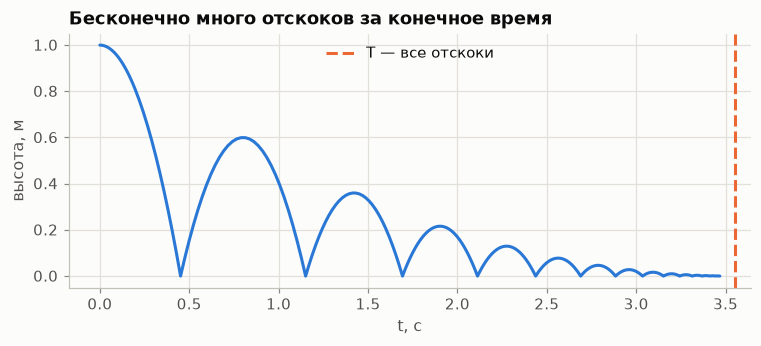

In [8]:
g, h0, r = 9.81, 1.0, 0.6
t0 = math.sqrt(2 * h0 / g)
path, time, h = h0, t0, h0
heights = []
for _ in range(1, 201):
    h *= r
    heights.append(h)
    path += 2 * h
    time += 2 * math.sqrt(2 * h / g)
print(f"мяч: путь {path:.6f} (формула {(1 + r) / (1 - r)}), время {time:.4f} с (формула {t0 * (1 + math.sqrt(r)) / (1 - math.sqrt(r)):.4f})")
print("отскоков до высоты < 1 мм:", next(k for k, hk in enumerate(heights, 1) if hk < 1e-3))
print("Ахиллес:", 100 / (1 - 0.1), "м; вечная рента 100 под 5 %:", round(sum(100 / 1.05**k for k in range(1, 3000)), 6))

fig, ax = plt.subplots(figsize=(8, 3))
tc, ts, ys = t0, list(np.linspace(0, t0, 40)), list(h0 - g * np.linspace(0, t0, 40) ** 2 / 2)
for k in range(1, 15):
    tk = 2 * math.sqrt(2 * h0 * r**k / g)
    tt = np.linspace(0, tk, 30)
    ts += list(tc + tt)
    ys += list(np.maximum(0, g * tk * tt / 2 - g * tt**2 / 2))
    tc += tk
ax.plot(ts, ys, color=BLUE, lw=2)
ax.axvline(t0 * (1 + math.sqrt(r)) / (1 - math.sqrt(r)), color=ORANGE, ls="--", label="T — все отскоки")
ax.set(xlabel="t, с", ylabel="высота, м", title="Бесконечно много отскоков за конечное время")
ax.legend()
plt.show()

### Шаг 9. $\sum k q^{k-1} = \frac{1}{(1-q)^2}$ и ожидание успеха

In [9]:
print("Σ k/2^k =", sum(k / 2**k for k in range(1, 200)), "; Σ k²/2^k =", sum(k * k / 2**k for k in range(1, 300)))
rng = Mulberry32(1)
waits = []
for _ in range(10000):
    k = 1
    while rng.random() >= 1 / 6:
        k += 1
    waits.append(k)
print(f"кубик до шестёрки: среднее в 10 000 опытах {np.mean(waits):.3f}, теория 1/p = 6; ряд: {sum(k * (5 / 6) ** (k - 1) / 6 for k in range(1, 2000)):.6f}")

Σ k/2^k = 2.0 ; Σ k²/2^k = 6.0
кубик до шестёрки: среднее в 10 000 опытах 5.962, теория 1/p = 6; ряд: 6.000000


### Шаг 10. Бустинг одного числа: остаток $(1-\nu)^M$

In [10]:
for nu in (0.05, 0.1, 0.3, 1.0, 1.5, 1.9, 2.0, 2.1):
    q = abs(1 - nu)
    steps = "никогда" if q >= 1 else (1 if q == 0 else math.ceil(math.log(0.01) / math.log(q)))
    print(f"ν = {nu:4}: q = {1 - nu:+.2f}, остаток после 10 шагов {(1 - nu) ** 10:+.4f}, шагов до 1 %: {steps}")
print("сумма всех поправок при ν = 0.3:", sum(0.3 * 10 * 0.7**m for m in range(500)), "= 10")

ν = 0.05: q = +0.95, остаток после 10 шагов +0.5987, шагов до 1 %: 90
ν =  0.1: q = +0.90, остаток после 10 шагов +0.3487, шагов до 1 %: 44
ν =  0.3: q = +0.70, остаток после 10 шагов +0.0282, шагов до 1 %: 13
ν =  1.0: q = +0.00, остаток после 10 шагов +0.0000, шагов до 1 %: 1
ν =  1.5: q = -0.50, остаток после 10 шагов +0.0010, шагов до 1 %: 7
ν =  1.9: q = -0.90, остаток после 10 шагов +0.3487, шагов до 1 %: 44
ν =  2.0: q = -1.00, остаток после 10 шагов +1.0000, шагов до 1 %: никогда
ν =  2.1: q = -1.10, остаток после 10 шагов +2.5937, шагов до 1 %: никогда
сумма всех поправок при ν = 0.3: 9.999999999999998 = 10


## Блок 3. Положительные ряды: признаки сходимости

### Шаги 11–12. Гармонический ряд, группы Орема, стопка книг, купоны

In [11]:
H = np.cumsum(1 / np.arange(1, 10**7 + 1))
for n in (10, 100, 1000, 10**6):
    print(f"H_{n:<7} = {H[n - 1]:.4f},  ln n + γ = {math.log(n) + np.euler_gamma:.4f}")
print("группы по 2^k членов:", [round(sum(1 / j for j in range(2**k + 1, 2 ** (k + 1) + 1)), 4) for k in range(8)])
print("H_n > 10 впервые при n =", int(np.argmax(H > 10)) + 1, "; H_n > 20 при n ≈", round(math.exp(20 - np.euler_gamma)))
print("книги: свес 1, 2, 3 при n =", [int(np.argmax(H / 2 >= t)) + 1 for t in (1, 2, 3)], "; 4 книги дают", H[3] / 2)
print("купоны: 6·H_6 =", 6 * H[5])
assert int(np.argmax(H > 10)) + 1 == 12367 and [int(np.argmax(H / 2 >= t)) + 1 for t in (1, 2, 3)] == [4, 31, 227]

H_10      = 2.9290,  ln n + γ = 2.8798
H_100     = 5.1874,  ln n + γ = 5.1824
H_1000    = 7.4855,  ln n + γ = 7.4850
H_1000000 = 14.3927,  ln n + γ = 14.3927
группы по 2^k членов: [0.5, 0.5833, 0.6345, 0.6629, 0.6778, 0.6854, 0.6893, 0.6912]
H_n > 10 впервые при n = 12367 ; H_n > 20 при n ≈ 272400600


книги: свес 1, 2, 3 при n = [4, 31, 227] ; 4 книги дают 1.0416666666666665
купоны: 6·H_6 = 14.7


### Шаг 13. Сравнение и предельный признак

In [12]:
k = np.arange(1, 10**6 + 1, dtype=float)
cases = {
    "1/(k²+1) ≤ 1/k²": 1 / (k**2 + 1),
    "(2k+1)/(k³+5) ~ 2/k²": (2 * k + 1) / (k**3 + 5),
    "1 − cos(1/k) ~ 1/(2k²)": 1 - np.cos(1 / k),
    "ln(1 + 1/k²) ~ 1/k²": np.log1p(1 / k**2),
    "sin(1/k) ~ 1/k (расх.)": np.sin(1 / k),
    "k/(k²+3) ~ 1/k (расх.)": k / (k**2 + 3),
}
for name, a in cases.items():
    print(f"{name:26}: S_1000 = {a[:1000].sum():.4f}, S_10⁶ = {a.sum():.4f}")

1/(k²+1) ≤ 1/k²           : S_1000 = 1.0757, S_10⁶ = 1.0767
(2k+1)/(k³+5) ~ 2/k²      : S_1000 = 1.6927, S_10⁶ = 1.6946
1 − cos(1/k) ~ 1/(2k²)    : S_1000 = 0.7783, S_10⁶ = 0.7788
ln(1 + 1/k²) ~ 1/k²       : S_1000 = 1.3008, S_10⁶ = 1.3018
sin(1/k) ~ 1/k (расх.)    : S_1000 = 7.2936, S_10⁶ = 14.2008
k/(k²+3) ~ 1/k (расх.)    : S_1000 = 6.3300, S_10⁶ = 13.2373


### Шаг 14. Интегральный признак, p-ряды, оценка остатка. Сверка с `scipy.special.zeta`

p = 1.1: S_100000 = 7.42217, ζ(p) = 10.58445
p = 1.5: S_100000 = 2.60605, ζ(p) = 2.61238
p = 2: S_100000 = 1.64492, ζ(p) = 1.64493
p = 3: S_100000 = 1.20206, ζ(p) = 1.20206
Σ1/k²: S_10 = 1.549768, оценки [1.640677, 1.649768], S_10 + 1/10.5 = 1.645006, π²/6 = 1.644934
Σ 1/(n ln n) до 10⁶ = 3.420 (растёт как ln ln n); Σ 1/(n ln² n) ≈ 2.1097


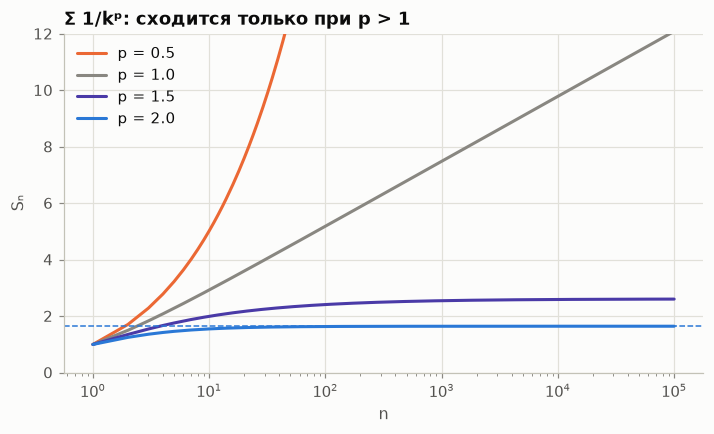

In [13]:
for p in (1.1, 1.5, 2, 3):
    s = np.sum(k[:100000] ** -p)
    print(f"p = {p}: S_100000 = {s:.5f}, ζ(p) = {special.zeta(p):.5f}")
S10 = np.sum(1 / k[:10] ** 2)
print(f"Σ1/k²: S_10 = {S10:.6f}, оценки [{S10 + 1 / 11:.6f}, {S10 + 1 / 10:.6f}], S_10 + 1/10.5 = {S10 + 1 / 10.5:.6f}, π²/6 = {math.pi**2 / 6:.6f}")
kk = np.arange(2, 10**6, dtype=float)
print(f"Σ 1/(n ln n) до 10⁶ = {np.sum(1 / (kk * np.log(kk))):.3f} (растёт как ln ln n); Σ 1/(n ln² n) ≈ {np.sum(1 / (kk * np.log(kk) ** 2)) + 1 / math.log(1e6):.4f}")
assert abs(S10 + 1 / 10.5 - math.pi**2 / 6) < 1e-4

fig, ax = plt.subplots(figsize=(7.5, 4))
n = np.arange(1, 100001)
for p, c in ((0.5, ORANGE), (1.0, MUTED), (1.5, VIOLET), (2.0, BLUE)):
    ax.semilogx(n, np.cumsum(n ** -float(p)), color=c, lw=2, label=f"p = {p}")
ax.axhline(math.pi**2 / 6, color=BLUE, ls="--", lw=1)
ax.set(ylim=(0, 12), xlabel="n", ylabel="Sₙ", title="Σ 1/kᵖ: сходится только при p > 1")
ax.legend()
plt.show()

### Шаги 15–16. Признаки Д’Аламбера и Коши; выбор признака

In [14]:
lg = lambda n: special.gammaln(n + 1)  # noqa: E731  ln n!
ratio_cases = {
    "n/2ⁿ": lambda n: np.log(n) - n * np.log(2),
    "2ⁿ/n!": lambda n: n * np.log(2) - lg(n),
    "n!/nⁿ": lambda n: lg(n) - n * np.log(n),
    "n¹⁰/1.1ⁿ": lambda n: 10 * np.log(n) - n * np.log(1.1),
    "3ⁿ/n³": lambda n: n * np.log(3) - 3 * np.log(n),
}
for name, la in ratio_cases.items():
    r = np.exp(la(1001.0) - la(1000.0))
    print(f"{name:10}: a₁₀₀₁/a₁₀₀₀ = {r:.5f}")
print("n¹⁰/1.1ⁿ: максимум члена при n =", int(np.argmax([10 * math.log(n) - n * math.log(1.1) for n in range(1, 400)])) + 1)
print("суммы: Σ n/2ⁿ =", sum(n / 2**n for n in range(1, 200)), "; Σ 2ⁿ/n! =", sum(2**n / math.factorial(n) for n in range(1, 60)), "= e² − 1 =", math.e**2 - 1)
print("Σ n!/nⁿ =", sum(math.exp(lg(n) - n * math.log(n)) for n in range(1, 200)), "; Σ (n/(2n+1))ⁿ =", sum((n / (2 * n + 1)) ** n for n in range(1, 200)))
print("Σ n³/3ⁿ =", sum(n**3 / 3**n for n in range(1, 200)), "= 33/8")

n/2ⁿ      : a₁₀₀₁/a₁₀₀₀ = 0.50050
2ⁿ/n!     : a₁₀₀₁/a₁₀₀₀ = 0.00200
n!/nⁿ     : a₁₀₀₁/a₁₀₀₀ = 0.36806
n¹⁰/1.1ⁿ  : a₁₀₀₁/a₁₀₀₀ = 0.91822
3ⁿ/n³     : a₁₀₀₁/a₁₀₀₀ = 2.99102
n¹⁰/1.1ⁿ: максимум члена при n = 105
суммы: Σ n/2ⁿ = 2.0 ; Σ 2ⁿ/n! = 6.38905609893065 = e² − 1 = 6.3890560989306495
Σ n!/nⁿ = 1.8798538621752585 ; Σ (n/(2n+1))ⁿ = 0.6497624069507308
Σ n³/3ⁿ = 4.125 = 33/8


## Блок 4. Ряды со знаками

### Шаг 17. Признак Лейбница и усреднение соседних сумм

In [15]:
L = partial_sums(lambda k: (-1) ** (k + 1) / k, 1001)
P = 4 * partial_sums(lambda k: (-1) ** (k + 1) / (2 * k - 1), 1001)
for m in (10, 100, 1000):
    err = abs(L[m - 1] - math.log(2))
    avg = abs((L[m - 1] + L[m]) / 2 - math.log(2))
    print(f"n = {m:4d}: ln 2 ≈ {L[m - 1]:.4f}, ошибка {err:.1e} ≤ {1 / (m + 1):.1e}; среднее соседних — ошибка {avg:.1e};  π ≈ {P[m - 1]:.4f}, среднее {(P[m - 1] + P[m]) / 2:.7f}")
E = partial_sums(lambda k: (-1) ** (k + 1) / math.factorial(k - 1), 10)
print("1/e за 10 членов: ошибка", abs(E[-1] - 1 / math.e), "≤ 1/10! =", 1 / math.factorial(10))

n =   10: ln 2 ≈ 0.6456, ошибка 4.8e-02 ≤ 9.1e-02; среднее соседних — ошибка 2.1e-03;  π ≈ 3.0418, среднее 3.1370777
n =  100: ln 2 ≈ 0.6882, ошибка 5.0e-03 ≤ 9.9e-03; среднее соседних — ошибка 2.5e-05;  π ≈ 3.1316, среднее 3.1415432
n = 1000: ln 2 ≈ 0.6926, ошибка 5.0e-04 ≤ 1.0e-03; среднее соседних — ошибка 2.5e-07;  π ≈ 3.1406, среднее 3.1415922
1/e за 10 членов: ошибка 2.5245892021352745e-07 ≤ 1/10! = 2.755731922398589e-07


### Шаг 18. Абсолютная и условная сходимость

In [16]:
for name, a in [("(−1)ᵏ⁺¹/k²", lambda k: (-1) ** (k + 1) / k**2), ("(−1)ᵏ⁺¹/k", lambda k: (-1) ** (k + 1) / k), ("(−1)ᵏ⁺¹/√k", lambda k: (-1) ** (k + 1) / math.sqrt(k)), ("sin k / k²", lambda k: math.sin(k) / k**2)]:
    s = partial_sums(a, 10**5)
    sa = partial_sums(lambda k, a=a: abs(a(k)), 10**5)
    print(f"{name:12}: Σa ≈ {(s[-1] + s[-2]) / 2:.5f}, Σ|a| до 10⁵ = {sa[-1]:.4f}")

(−1)ᵏ⁺¹/k²  : Σa ≈ 0.82247, Σ|a| до 10⁵ = 1.6449
(−1)ᵏ⁺¹/k   : Σa ≈ 0.69315, Σ|a| до 10⁵ = 12.0901
(−1)ᵏ⁺¹/√k  : Σa ≈ 0.60490, Σ|a| до 10⁵ = 630.9968
sin k / k²  : Σa ≈ 1.01396, Σ|a| до 10⁵ = 1.2799


### Шаг 19. Теорема Римана: перестановка меняет сумму

In [17]:
def rearranged(p, q, blocks=100000):
    s, i, j = 0.0, 0, 0
    for _ in range(blocks):
        for _ in range(p):
            s += 1 / (2 * i + 1)
            i += 1
        for _ in range(q):
            s -= 1 / (2 * j + 2)
            j += 1
    return s


for p, q in [(1, 1), (1, 2), (2, 1), (1, 4), (4, 1)]:
    print(f"p = {p}, q = {q}: {rearranged(p, q):.5f}   ln 2 + ½ ln(p/q) = {math.log(2) + 0.5 * math.log(p / q):.5f}")


def greedy(target, n=20000):
    s, i, j = 0.0, 0, 0
    for _ in range(n):
        if s <= target:
            s += 1 / (2 * i + 1)
            i += 1
        else:
            s -= 1 / (2 * j + 2)
            j += 1
    return s


print("жадная перестановка к целям −1, 0, 1.5, π:", [round(greedy(t), 4) for t in (-1, 0, 1.5, math.pi)])

p = 1, q = 1: 0.69314   ln 2 + ½ ln(p/q) = 0.69315
p = 1, q = 2: 0.34657   ln 2 + ½ ln(p/q) = 0.34657
p = 2, q = 1: 1.03972   ln 2 + ½ ln(p/q) = 1.03972
p = 1, q = 4: -0.00000   ln 2 + ½ ln(p/q) = 0.00000


p = 4, q = 1: 1.38629   ln 2 + ½ ln(p/q) = 1.38629
жадная перестановка к целям −1, 0, 1.5, π: [-0.9996, -0.0, 1.5, 3.1409]


## Блок 5. Степенные ряды

### Шаги 20–21. Радиус сходимости и почленные действия

In [18]:
print("Σ xᵏ/k при x = −1:", partial_sums(lambda k: (-1) ** k / k, 10**6)[-1], " = −ln 2")
for x in (0.5, 0.9, 1.5):
    S = partial_sums(lambda k, x=x: (-1) ** (k + 1) * x**k / k, 40)
    print(f"ln(1 + {x}) = {math.log1p(x):.4f};  ряд: S_10 = {S[9]:.4f}, S_40 = {S[39]:.4g}")


def atan_series(x, n):
    return sum((-1) ** k * x ** (2 * k + 1) / (2 * k + 1) for k in range(n))


for n in (1, 2, 3, 5, 8):
    pi_m = 16 * atan_series(1 / 5, n) - 4 * atan_series(1 / 239, n)
    print(f"Мэчин, {n} членов: π ≈ {pi_m:.13f}, ошибка {abs(pi_m - math.pi):.1e}")
print("Лейбниц, 1000 членов:", 4 * atan_series(1, 1000))

Σ xᵏ/k при x = −1: -0.6931466805602525  = −ln 2
ln(1 + 0.5) = 0.4055;  ряд: S_10 = 0.4054, S_40 = 0.4055
ln(1 + 0.9) = 0.6419;  ряд: S_10 = 0.6262, S_40 = 0.6417
ln(1 + 1.5) = 0.9163;  ряд: S_10 = -2.4031, S_40 = -1.642e+05
Мэчин, 1 членов: π ≈ 3.1832635983264, ошибка 4.2e-02
Мэчин, 2 членов: π ≈ 3.1405970293261, ошибка 1.0e-03
Мэчин, 3 членов: π ≈ 3.1416210293250, ошибка 2.8e-05
Мэчин, 5 членов: π ≈ 3.1415926824044, ошибка 2.9e-08
Мэчин, 8 членов: π ≈ 3.1415926535886, ошибка 1.2e-12
Лейбниц, 1000 членов: 3.1405926538397932


### Шаг 22. Ряды Тейлора и катастрофическое сокращение

In [19]:
print("e по ряду:", [sum(1 / math.factorial(k) for k in range(n)) for n in (3, 5, 10, 15)])
for N in (5, 10, 20, 30):
    print(f"sin 10 рядом в нуле, {N} членов: {sum((-1) ** k * 10 ** (2 * k + 1) / math.factorial(2 * k + 1) for k in range(N)):.10f}")
print("sin(10 − 4π), 6 членов:", sum((-1) ** k * (10 - 4 * math.pi) ** (2 * k + 1) / math.factorial(2 * k + 1) for k in range(6)), " точно", math.sin(10))


def exp_series(x, n=200):
    s, term = 0.0, 1.0
    for k in range(1, n):
        s += term
        term *= x / k
    return s


print(f"e^-20: ряд {exp_series(-20):.4e}, 1/ряд(20) {1 / exp_series(20):.4e}, точно {math.exp(-20):.4e}")

e по ряду: [2.5, 2.7083333333333335, 2.7182815255731922, 2.7182818284582297]
sin 10 рядом в нуле, 5 членов: 1448.2716049383
sin 10 рядом в нуле, 10 членов: -16.8118501374
sin 10 рядом в нуле, 20 членов: -0.5440211137
sin 10 рядом в нуле, 30 членов: -0.5440211109
sin(10 − 4π), 6 членов: -0.5439884997141442  точно -0.5440211108893698
e^-20: ряд 6.1476e-09, 1/ряд(20) 2.0612e-09, точно 2.0612e-09


### Шаг 23. Радиус = расстояние до особой точки. Логистические потери: $R = \sqrt{F_0^2 + \pi^2}$

Коэффициенты Тейлора считаем по формуле Коши (БПФ на окружности радиуса $r < R$) и сверяем с известными:
первая и вторая производные $\ln(1 + e^F)$ — это $\sigma(F)$ и $\sigma(1 - \sigma)$, градиент и гессиан XGBoost.

In [20]:
def softplus(z):
    return np.where(z.real <= 0, np.log1p(np.exp(z)), z + np.log1p(np.exp(-z)))


def taylor_coefs(f, a, r, K, N=512):
    th = 2 * np.pi * np.arange(N) / N
    return (np.fft.fft(f(a + r * np.exp(1j * th))) / N).real[: K + 1] / r ** np.arange(K + 1)


for F0 in (0.0, 2.0):
    R = math.hypot(F0, math.pi)
    c = taylor_coefs(softplus, F0, 0.92 * R, 40)
    sig = 1 / (1 + math.exp(-F0))
    print(f"F0 = {F0}: R = {R:.4f}; c1 = {c[1]:.6f} (σ = {sig:.6f}), 2c2 = {2 * c[2]:.6f} (σ(1 − σ) = {sig * (1 - sig):.6f}); |c40|^(−1/40) = {abs(c[40]) ** (-1 / 40):.3f}")
    assert abs(c[1] - sig) < 1e-9 and abs(2 * c[2] - sig * (1 - sig)) < 1e-9
    for d in (0.5 * R, 0.9 * R, 1.2 * R):
        S = sum(ck * d**k for k, ck in enumerate(c))
        print(f"    ΔF = {d:5.2f}: ряд из 41 члена {S:12.5f}, функция {np.logaddexp(0, F0 + d):.5f}")
a = 2.0
c = [(-1) ** k * (1 / (a - 1j) ** (k + 1)).imag for k in range(41)]
print("1/(1 + x²) в точке 2: |c40|^(−1/40) =", round(abs(c[40]) ** (-1 / 40), 3), " √5 =", round(math.sqrt(5), 3))

F0 = 0.0: R = 3.1416; c1 = 0.500000 (σ = 0.500000), 2c2 = 0.250000 (σ(1 − σ) = 0.250000); |c40|^(−1/40) = 3.386
    ΔF =  1.57: ряд из 41 члена      1.75966, функция 1.75966
    ΔF =  2.83: ряд из 41 члена      2.88459, функция 2.88491
    ΔF =  3.77: ряд из 41 члена    -38.68189, функция 3.79270
F0 = 2.0: R = 3.7242; c1 = 0.880797 (σ = 0.880797), 2c2 = 0.104994 (σ(1 − σ) = 0.104994); |c40|^(−1/40) = 4.040
    ΔF =  1.86: ряд из 41 члена      3.88290, функция 3.88290
    ΔF =  3.35: ряд из 41 члена      5.35689, функция 5.35650
    ΔF =  4.47: ряд из 41 члена     50.47732, функция 6.47058
1/(1 + x²) в точке 2: |c40|^(−1/40) = 2.389  √5 = 2.236


## Блок 6. Ряды из функций

### Шаг 24. Ряд Фурье (анимация) и явление Гиббса

In [21]:
x = np.linspace(-np.pi, np.pi, 4001)


def square_partial(N):
    return 4 / np.pi * sum(np.sin((2 * k + 1) * x) / (2 * k + 1) for k in range(N))


def tri_partial(N):
    return np.pi / 2 - 4 / np.pi * sum(np.cos((2 * k + 1) * x) / (2 * k + 1) ** 2 for k in range(N))


print("максимум меандра при N = 1, 3, 10, 50:", [round(float(square_partial(N).max()), 4) for N in (1, 3, 10, 50)], "(Гиббс → 1.17898)")
print("треугольник: наибольшая ошибка при N = 5, 20:", [round(float(np.abs(tri_partial(N) - np.abs(x)).max()), 4) for N in (5, 20)])

fig, ax = plt.subplots(figsize=(7, 3.6), dpi=72)
Ns = [1, 2, 3, 5, 8, 13, 21, 34, 50]


def frame(i):
    ax.clear()
    ax.plot(x, np.sign(x), "--", color=MUTED)
    ax.plot(x, square_partial(Ns[i]), color=BLUE, lw=2)
    ax.axhline(1.179, color=RED, ls=":", lw=1)
    ax.set(ylim=(-1.5, 1.5), title=f"сумма {Ns[i]} синусов")
    return []


anim = animation.FuncAnimation(fig, frame, frames=len(Ns), interval=700)
plt.close(fig)
display(HTML(anim.to_jshtml()))

максимум меандра при N = 1, 3, 10, 50: [1.2732, 1.1884, 1.1798, 1.179] (Гиббс → 1.17898)
треугольник: наибольшая ошибка при N = 5, 20: [0.0635, 0.0159]


### Шаг 25. Равенство Парсеваля и задача Базеля

In [22]:
energy_saw = 2 * np.pi**2 / 3
print("пила: (1/π)∫x² =", energy_saw, "; Σ (2/k)² =", sum(4 / k**2 for k in range(1, 10**6)), "⇒ Σ1/k² = π²/6")
b2 = [16 / (np.pi**2 * (2 * j + 1) ** 2) for j in range(10)]
print("меандр: доля энергии в 1, 3, 10 волнах:", [round(sum(b2[:N]) / 2, 4) for N in (1, 3, 10)])

пила: (1/π)∫x² = 6.579736267392906 ; Σ (2/k)² = 6.579732267390906 ⇒ Σ1/k² = π²/6
меандр: доля энергии в 1, 3, 10 волнах: [0.8106, 0.9331, 0.9798]


## Блок 7. Ряды в машинном обучении

### Шаги 26–27. Модель бустинга — частичная сумма; ν·M ≈ const; сверка с scikit-learn

MSE истинной функции на проверке (неустранимый шум): 0.1512
ν = 0.03: лучшее M = 162, ν·M = 4.86, MSE = 0.1802; размер члена m = 1, 10: 0.0281, 0.0220
ν = 0.1: лучшее M = 46, ν·M = 4.60, MSE = 0.1800; размер члена m = 1, 10: 0.0935, 0.0377
ν = 0.3: лучшее M = 17, ν·M = 5.10, MSE = 0.1800; размер члена m = 1, 10: 0.2806, 0.0208
ν = 1.0: лучшее M = 3, ν·M = 3.00, MSE = 0.2083; размер члена m = 1, 10: 0.9352, 0.0222


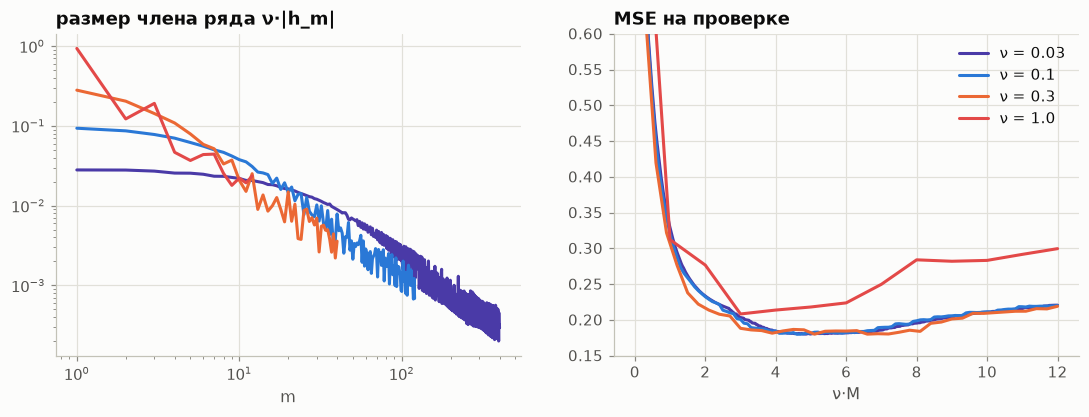

scikit-learn, ν = 0.1: лучшее M = 46 , MSE 0.18


In [23]:
X, y = datasets.regression_1d(kind="wave", n=160, noise=0.45, seed=11)
Xtr, Xte, ytr, yte = datasets.train_test_split(X, y, test_size=0.5, seed=3)
print("MSE истинной функции на проверке (неустранимый шум):", round(float(np.mean((yte - (np.sin(Xte[:, 0]) + 0.3 * Xte[:, 0])) ** 2)), 4))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for nu, c in ((0.03, VIOLET), (0.1, BLUE), (0.3, ORANGE), (1.0, RED)):
    M = math.ceil(12 / nu)
    model = GBRegressor(n_estimators=M, learning_rate=nu, max_depth=2).fit(Xtr, ytr)
    te = [float(np.mean((yte - model.init_) ** 2))] + [float(np.mean((yte - F) ** 2)) for F in model.staged_predict_raw(Xte)]
    tr_stages = [np.full(len(ytr), model.init_)] + list(model.staged_predict_raw(Xtr))
    sizes = [float(np.mean(np.abs(tr_stages[m] - tr_stages[m - 1]))) for m in range(1, M + 1)]
    best = int(np.argmin(te))
    print(f"ν = {nu}: лучшее M = {best}, ν·M = {nu * best:.2f}, MSE = {te[best]:.4f}; размер члена m = 1, 10: {sizes[0]:.4f}, {sizes[min(9, M - 1)]:.4f}")
    axes[0].loglog(range(1, M + 1), sizes, color=c, label=f"ν = {nu}")
    axes[1].plot(nu * np.arange(M + 1), te, color=c, label=f"ν = {nu}")
axes[0].set(title="размер члена ряда ν·|h_m|", xlabel="m")
axes[1].set(title="MSE на проверке", xlabel="ν·M", ylim=(0.15, 0.6))
axes[1].legend()
plt.show()

try:
    from sklearn.ensemble import GradientBoostingRegressor

    sk = GradientBoostingRegressor(n_estimators=120, learning_rate=0.1, max_depth=2).fit(Xtr, ytr)
    sk_te = [np.mean((yte - p) ** 2) for p in sk.staged_predict(Xte)]
    print("scikit-learn, ν = 0.1: лучшее M =", int(np.argmin(sk_te)) + 1, ", MSE", round(min(sk_te), 4))
except ImportError:
    print("scikit-learn не установлен — пропускаем")

### Шаг 28. Экспоненциальное среднее, поправка Adam, моментум

In [24]:
beta = 0.9
print("вес последних 10 наблюдений:", 1 - beta**10, "; средний возраст β/(1 − β) =", sum(j * (1 - beta) * beta**j for j in range(2000)))
print("сумма весов при t = 5:", 1 - beta**5, "; при β₂ = 0.999 и t = 10:", 1 - 0.999**10)
rng = Mulberry32(3)
g_obs = [rng.normal(2, 1) for _ in range(100)]
m = 0.0
for t in range(1, 21):
    m = beta * m + (1 - beta) * g_obs[t - 1]
print(f"t = 20: m = {m:.4f}, с поправкой {m / (1 - beta**20):.4f}")
v = 0.0
for _ in range(200):
    v = beta * v + 1.0
print("моментум при градиенте 1: скорость →", v, "= 1/(1 − β)")

вес последних 10 наблюдений: 0.6513215599 ; средний возраст β/(1 − β) = 9.000000000000002
сумма весов при t = 5: 0.40950999999999993 ; при β₂ = 0.999 и t = 10: 0.009955119790251765
t = 20: m = 1.7605, с поправкой 2.0041
моментум при градиенте 1: скорость → 9.999999992944923 = 1/(1 − β)


### Шаг 29. Условия Роббинса — Монро

$\theta_k = \theta_{k-1} + \nu_k(y_k - \theta_{k-1})$ — SGD для потерь $\frac12(\theta - y)^2$; 200 повторов с разными зёрнами.

In [25]:
SCHED = {"const 0.05": lambda k: 0.05, "1/k": lambda k: 1 / k, "1/k^0.6": lambda k: k**-0.6, "1/k²": lambda k: 1 / k**2}
K = 2000
errs = {name: [] for name in SCHED}
for seed in range(1, 201):
    rng = Mulberry32(seed)
    ys_ = [rng.normal(2.0, 1.0) for _ in range(K)]
    for name, nu in SCHED.items():
        th = 0.0
        for kk_, yk in enumerate(ys_, start=1):
            th += nu(kk_) * (yk - th)
        errs[name].append(th - 2)
for name, e in errs.items():
    print(f"{name:11}: разброс ошибки {np.std(e):.4f}; Σν = {sum(SCHED[name](i) for i in range(1, K + 1)):.3f}")
print("теория: const √(ν/(2 − ν)) =", round(math.sqrt(0.05 / 1.95), 4), "; 1/k: 1/√K =", round(1 / math.sqrt(K), 4))
print("Π (1 − 1/k²), k ≥ 2 =", np.prod(1 - 1 / np.arange(2, 10**6, dtype=float) ** 2), "(телескоп: ½)")

const 0.05 : разброс ошибки 0.1618; Σν = 100.000
1/k        : разброс ошибки 0.0218; Σν = 8.178
1/k^0.6    : разброс ошибки 0.0755; Σν = 50.335
1/k²       : разброс ошибки 0.5445; Σν = 1.644
теория: const √(ν/(2 − ν)) = 0.1601 ; 1/k: 1/√K = 0.0224
Π (1 − 1/k²), k ≥ 2 = 0.5000004999837107 (телескоп: ½)


### Шаг 30. L2-бустинг со сглаживателем — матричный геометрический ряд

Итерации $F_m = F_{m-1} + \nu S(y - F_{m-1})$ совпадают с рядом по частотам $F_M = \mathcal F^{-1}\bigl[(1 - (1 - \nu\lambda_k)^M)\hat y_k\bigr]$.

In [26]:
n, nu, b = 64, 0.1, 2.0
xg = 2 * np.pi * np.arange(n) / n
f_true = np.sin(xg) + 0.5 * np.sin(3 * xg)
rng = Mulberry32(5)
yg = f_true + np.array([rng.normal(0, 0.5) for _ in range(n)])
d = np.minimum(np.arange(n), n - np.arange(n))
w = np.exp(-(d**2) / (2 * b * b))
w /= w.sum()
Smat = np.array([[w[(i - j) % n] for j in range(n)] for i in range(n)])
lam = np.real(np.fft.fft(w))
F = np.zeros(n)
err = []
for M in range(1, 401):
    F = F + nu * Smat @ (yg - F)
    err.append(np.mean((F - f_true) ** 2))
    if M == 37:
        F_spec = np.real(np.fft.ifft(np.fft.fft(yg) * (1 - (1 - nu * lam) ** M)))
        print("M = 37: итерации == ряд по частотам, расхождение", np.max(np.abs(F - F_spec)))
best = int(np.argmin(err)) + 1
print(f"λ₁, λ₃, λ₁₀ = {lam[1]:.3f}, {lam[3]:.3f}, {lam[10]:.3f}; лучшее M = {best}, ошибка до истины {err[best - 1]:.4f}; при M = 400 — {err[-1]:.4f}")
for M in (5, best, 100, 400):
    print(f"  M = {M:3d}: подогнано на частотах 1, 3, 10, 20:", [round(float(1 - (1 - nu * lam[k]) ** M), 3) for k in (1, 3, 10, 20)])

M = 37: итерации == ряд по частотам, расхождение 9.992007221626409e-16
λ₁, λ₃, λ₁₀ = 0.981, 0.841, 0.145; лучшее M = 22, ошибка до истины 0.0321; при M = 400 — 0.0905
  M =   5: подогнано на частотах 1, 3, 10, 20: [0.403, 0.355, 0.071, 0.0]
  M =  22: подогнано на частотах 1, 3, 10, 20: [0.897, 0.855, 0.276, 0.001]
  M = 100: подогнано на частотах 1, 3, 10, 20: [1.0, 1.0, 0.769, 0.004]
  M = 400: подогнано на частотах 1, 3, 10, 20: [1.0, 1.0, 0.997, 0.018]


## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ Сумма $3 + 1 + \frac13 + \dots$ и $\sum \frac{2^k + 3^k}{6^k}$.
2. ★☆☆ Бустинг одного числа с ν = 0.3 и 0.1: остаток после 10 шагов и шаги до 1 %.
3. ★☆☆ Периодические дроби $0.(27)$ и $0.4(16)$.
4. ★★☆ Телескоп: $\sum \frac{1}{k^2 + 3k + 2}$ и $\sum \frac{1}{4k^2 - 1}$.
5. ★★☆ Гармонический ряд: когда сумма превысит 10; сравнение с $e^{10 - \gamma}$.
6. ★★☆ Сравнение и интегральный признак: пять рядов; оценка суммы $\sum \frac1{k^3}$ по десяти членам.
7. ★★☆ Признак отношения для $\sum \frac{n^2}{2^n}$, $\sum \frac{3^n}{n!}$, $\sum \frac{n!}{n^n}$.
8. ★★☆ Знакочередующиеся: сколько членов нужно для ошибки $10^{-4}$; усреднение.
9. ★★★ Радиус и интервал сходимости трёх степенных рядов; концы.
10. ★★★ Перестановка «два плюса, один минус» для $1 - \frac12 + \frac13 - \dots$.
11. ★★★ Ряд Фурье пилы и Парсеваль; $\sum \frac{1}{k^4}$ из треугольной волны.
12. ★★★ Бустинг: ν·M на данных урока и экспоненциальное среднее с поправкой.